In [1]:
#import all import libraries
import torch
import torchvision
import seaborn as sb
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F
from torch.utils.data import DataLoader,Dataset
from torchvision import transforms
from torchvision import datasets
from torch import optim
from torch.nn import Sequential
from torchvision.datasets import ImageFolder
from collections import OrderedDict
from torch import nn
import warnings
from torchvision import models
import time
warnings.filterwarnings("ignore")

C:\Users\romun\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
#create a transformer
transformer = transforms.Compose([transforms.Resize((256,256)),
                                  transforms.ToTensor(),
                                  transforms.Normalize((.2,),(0.3,))])

In [10]:
path ="10264/"

In [11]:
train_data = ImageFolder(path+'/train', transform=transformer)

In [12]:
valid_data = ImageFolder(path+'/valid',transform=transformer)

In [13]:
train_data.class_to_idx

{'0': 0, '1': 1}

In [14]:
def img_show(images, normalize=True, mean=0.5, std=0.5):
    sb.set_style("whitegrid")
    fig, axes = plt.subplots(figsize=(15,10), ncols=5)

    for i in range(5):
        image = images[i][0]  # get image tensor
        image = image.numpy().transpose(1,2,0)  # CHW -> HWC

        if normalize:  # unnormalize
            image = std * image + mean

        image = np.clip(image, 0, 1)  # keep pixel values in [0,1]

        axes[i].imshow(image.squeeze(), cmap="gray" if image.shape[2]==1 else None)
        axes[i].set_xticks([])
        axes[i].set_yticks([])
        axes[i].grid(False)


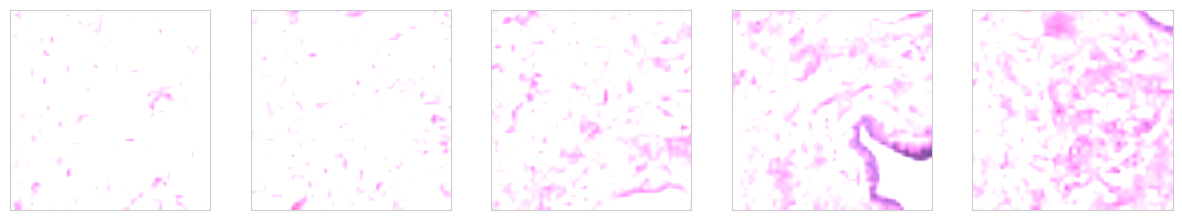

In [15]:
img_show(images=train_data,normalize=True)

In [16]:
trainloader = DataLoader(train_data, batch_size=32, shuffle=True, num_workers=0)
validloader = DataLoader(valid_data, batch_size=32, shuffle=False, num_workers=0)

In [17]:
model = models.resnet50(pretrained=True)
model

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to C:\Users\romun/.cache\torch\hub\checkpoints\resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:32<00:00, 3.18MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [18]:
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs,2)

In [19]:
dataiter = iter(trainloader)
images,labels = next(dataiter)

In [20]:
images.shape

torch.Size([32, 3, 256, 256])

In [21]:
labels.shape

torch.Size([32])

In [22]:
log_ps = model(images)

In [23]:
torch.exp(log_ps).shape

torch.Size([32, 2])

In [30]:
#create  a criterion 
criterion = nn.NLLLoss()

In [31]:
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=0.01)
lr_sched = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)  # slower decay


In [32]:
def training(model, optimizer, criterion, lr_sched, num_epoch):
    import time
    since = time.time()
    
    # Lists to store metrics
    train_losses = []
    valid_losses = []
    train_accuracies = []
    valid_accuracies = []
    
    for epoch in range(num_epoch):
        # Per-epoch accumulation
        running_train_loss = 0
        running_train_acc = 0
        
        # --- Training loop ---
        for images, labels in trainloader:
            log_ps = model(images)
            optimizer.zero_grad()
            loss = criterion(log_ps, labels)
            
            # Accuracy calculation
            proba = torch.exp(log_ps)
            _, topk_classes = proba.topk(1, dim=1)
            equals = topk_classes == labels.view(topk_classes.shape)
            running_train_acc += torch.mean(equals.float())
            
            loss.backward()
            optimizer.step()
            
            running_train_loss += loss.item()
        
        # --- Validation loop ---
        model.eval()
        running_valid_loss = 0
        running_valid_acc = 0
        with torch.no_grad():
            for images, labels in validloader:
                log_ps = model(images)
                loss = criterion(log_ps, labels)
                
                proba = torch.exp(log_ps)
                _, topk_classes = proba.topk(1, dim=1)
                equals = topk_classes == labels.view(topk_classes.shape)
                running_valid_acc += torch.mean(equals.float())
                running_valid_loss += loss.item()
        model.train()
        
        # --- Store epoch metrics ---
        train_losses.append(running_train_loss / len(trainloader))
        train_accuracies.append(running_train_acc / len(trainloader))
        valid_losses.append(running_valid_loss / len(validloader))
        valid_accuracies.append(running_valid_acc / len(validloader))
        
        lr_sched.step()
        
        # --- Print progress ---
        print('--'*10)
        print(f"Epoch {epoch+1}/{num_epoch}")
        print(f"Train Loss: {train_losses[-1]:.5f} | Valid Loss: {valid_losses[-1]:.5f} | Valid Acc: {valid_accuracies[-1]:.5f}")
    
    time_elapsed = time.time() - since
    print(f"Training complete in {time_elapsed//60:.0f}m {time_elapsed%60:.0f}s")
    
    best_parameters = model.state_dict()
    return model, best_parameters, train_losses, valid_losses, train_accuracies, valid_accuracies


In [33]:
model, best_params, train_loss, valid_loss, train_accuracies, valid_accuracies = training(
    model=model,
    optimizer=optimizer,
    criterion=criterion,
    lr_sched=lr_sched,
    num_epoch=100
)

--------------------
Epoch 1/100
Train Loss: -138.12953 | Valid Loss: -145.89745 | Valid Acc: 0.92193
--------------------
Epoch 2/100
Train Loss: -192.49479 | Valid Loss: -191.96809 | Valid Acc: 0.45982
--------------------
Epoch 3/100
Train Loss: -245.93665 | Valid Loss: -263.37330 | Valid Acc: 0.45982
--------------------
Epoch 4/100
Train Loss: -312.14393 | Valid Loss: -341.02824 | Valid Acc: 0.45982
--------------------
Epoch 5/100
Train Loss: -389.14474 | Valid Loss: -401.73405 | Valid Acc: 0.45982
--------------------
Epoch 6/100
Train Loss: -470.90062 | Valid Loss: -454.10629 | Valid Acc: 0.45982
--------------------
Epoch 7/100
Train Loss: -570.47539 | Valid Loss: -603.54322 | Valid Acc: 0.45982
--------------------
Epoch 8/100
Train Loss: -672.67389 | Valid Loss: -707.67700 | Valid Acc: 0.45982
--------------------
Epoch 9/100
Train Loss: -791.35660 | Valid Loss: -802.74263 | Valid Acc: 0.45982
--------------------
Epoch 10/100
Train Loss: -914.50685 | Valid Loss: -997.14783 

--------------------
Epoch 80/100
Train Loss: -1157.87971 | Valid Loss: -1146.98973 | Valid Acc: 0.45982
--------------------
Epoch 81/100
Train Loss: -1155.08049 | Valid Loss: -1151.32540 | Valid Acc: 0.45982
--------------------
Epoch 82/100
Train Loss: -1156.81531 | Valid Loss: -1153.48115 | Valid Acc: 0.45982
--------------------
Epoch 83/100
Train Loss: -1148.51212 | Valid Loss: -1145.55354 | Valid Acc: 0.45982
--------------------
Epoch 84/100
Train Loss: -1156.10364 | Valid Loss: -1140.94346 | Valid Acc: 0.45982
--------------------
Epoch 85/100
Train Loss: -1155.51266 | Valid Loss: -1153.76722 | Valid Acc: 0.45982
--------------------
Epoch 86/100
Train Loss: -1159.06800 | Valid Loss: -1152.23306 | Valid Acc: 0.45982
--------------------
Epoch 87/100
Train Loss: -1152.70869 | Valid Loss: -1145.70592 | Valid Acc: 0.45982
--------------------
Epoch 88/100
Train Loss: -1158.54871 | Valid Loss: -1148.93104 | Valid Acc: 0.45982
--------------------
Epoch 89/100
Train Loss: -1152.173

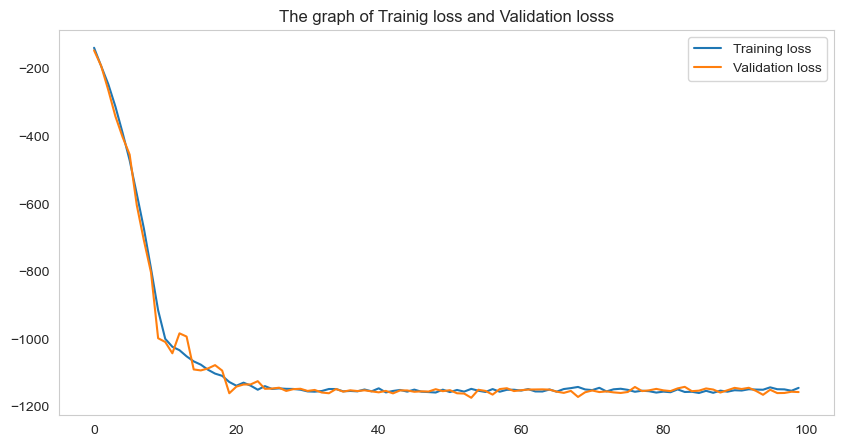

In [35]:
sb.set_style("whitegrid")
plt.figure(figsize=(10,5))
plt.title("The graph of Trainig loss and Validation losss")
plt.plot(train_loss,label="Training loss")
plt.plot(valid_loss,label="Validation loss")
plt.grid(False)
plt.legend()
plt.show()

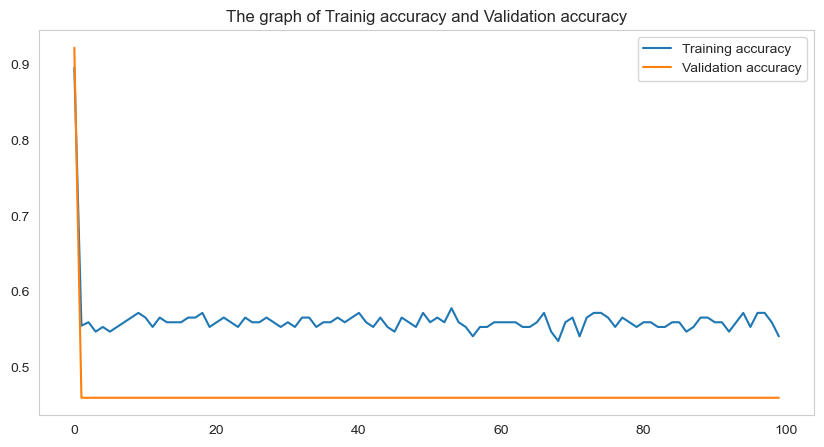

In [36]:
sb.set_style("whitegrid")
plt.figure(figsize=(10,5))
plt.title("The graph of Trainig accuracy and Validation accuracy")
plt.plot(train_accuracies,label="Training accuracy")
plt.plot(valid_accuracies,label="Validation accuracy")
plt.grid(False)
plt.legend()
plt.show()

In [38]:
model.eval()
images, labels = next(iter(validloader))     # use validloader, not testloader
actual_label = labels[10].item()
predicted_label = model(images[10].unsqueeze(0))  # keep [1, 3, 256, 256] shape
label_proba = F.softmax(predicted_label, dim=1)   # convert logits → probabilities

In [39]:
label_proba

tensor([[1., 0.]], grad_fn=<SoftmaxBackward0>)

In [40]:
topk_class,topk_idx = label_proba.topk(1,dim=1)

In [41]:
print("Predicted class : ", topk_idx.item(), end=" | ")
print("Actual class : ", actual_label)

Predicted class :  0 | Actual class :  0


In [42]:
class_names = train_data.classes   # ['0', '1']

print("Predicted class : ", class_names[topk_idx.item()], end=" | ")
print("Actual class : ", class_names[actual_label])


Predicted class :  0 | Actual class :  0


In [43]:
torch.save(model, "breast_cancer_resnet50_full.pth")